In [123]:
import pandas as pd
import numpy as np

In [124]:
def transform_sex(value):
    if value == "female":
        return 1
    else:
        return 0

In [125]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
    
train["Sex_binary"] = train["Sex"].map(transform_sex)
test["Sex_binary"] = test["Sex"].map(transform_sex)

In [126]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_binary
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [127]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedKFold

In [128]:
%matplotlib inline

### New variables

In [129]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_binary
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [130]:
variables = ["Sex_binary", "Age", "Pclass", "SibSp", "Parch", "Fare"]

In [131]:
x = train[variables].fillna(-1)
y = train["Survived"]

In [132]:
results = []

for rep in range(10):
    print("Rep:", rep)
    kf = RepeatedKFold(n_splits=2, n_repeats=10, random_state=10)

    for lines_train, lines_valid in kf.split(x):
        print("Train:", lines_train.shape[0])
        print("Valid:", lines_valid.shape[0])

        x_train, x_valid = x.iloc[lines_train], x.iloc[lines_valid]
        y_train, y_valid = y.iloc[lines_train], y.iloc[lines_valid]

        model = RandomForestClassifier(n_estimators=100, n_jobs=1, random_state=0)
        model.fit(x_train, y_train)

        p = model.predict(x_valid)

        acc = np.mean(y_valid == p)
        results.append(acc)
        print("Acc:", acc)
        print()

Rep: 0
Train: 445
Valid: 446
Acc: 0.7869955156950673

Train: 446
Valid: 445
Acc: 0.7797752808988764

Train: 445
Valid: 446
Acc: 0.827354260089686

Train: 446
Valid: 445
Acc: 0.8179775280898877

Train: 445
Valid: 446
Acc: 0.7847533632286996

Train: 446
Valid: 445
Acc: 0.7842696629213484

Train: 445
Valid: 446
Acc: 0.8161434977578476

Train: 446
Valid: 445
Acc: 0.7842696629213484

Train: 445
Valid: 446
Acc: 0.8004484304932735

Train: 446
Valid: 445
Acc: 0.8

Train: 445
Valid: 446
Acc: 0.8183856502242153

Train: 446
Valid: 445
Acc: 0.802247191011236

Train: 445
Valid: 446
Acc: 0.8116591928251121

Train: 446
Valid: 445
Acc: 0.8067415730337079

Train: 445
Valid: 446
Acc: 0.820627802690583

Train: 446
Valid: 445
Acc: 0.7887640449438202

Train: 445
Valid: 446
Acc: 0.8385650224215246

Train: 446
Valid: 445
Acc: 0.8044943820224719

Train: 445
Valid: 446
Acc: 0.7982062780269058

Train: 446
Valid: 445
Acc: 0.8112359550561797

Rep: 1
Train: 445
Valid: 446
Acc: 0.7869955156950673

Train: 446
Valid:

(array([40., 20.,  0., 40., 20., 20., 40.,  0., 10., 10.]),
 array([0.77977528, 0.78565426, 0.79153323, 0.7974122 , 0.80329118,
        0.80917015, 0.81504913, 0.8209281 , 0.82680707, 0.83268605,
        0.83856502]),
 <BarContainer object of 10 artists>)

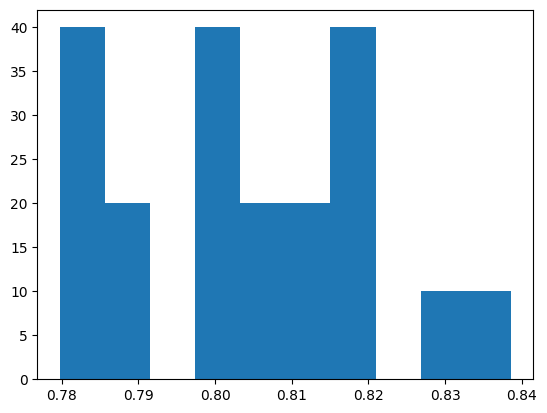

In [133]:
matplotlib.pylab.hist(results)

In [134]:
np.mean(results)

0.8041457147175897

### Retrain the model

In [135]:
x.head()

,Sex_binary,Age,Pclass,SibSp,Parch,Fare
0,0,22.0,3,1,0,7.2500
1,1,38.0,1,1,0,71.2833
2,1,26.0,3,0,0,7.9250
3,1,35.0,1,1,0,53.1000
4,0,35.0,3,0,0,8.0500


In [136]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [137]:
test[variables].head()

,Sex_binary,Age,Pclass,SibSp,Parch,Fare
0,0,34.5,3,0,0,7.8292
1,1,47.0,3,1,0,7.0000
2,0,62.0,2,0,0,9.6875
3,0,27.0,3,0,0,8.6625
4,1,22.0,3,1,1,12.2875


In [138]:
model = RandomForestClassifier(n_estimators=100, n_jobs=1, random_state=0)
model.fit(x, y)

p = model.predict(test[variables].fillna(-1))

In [139]:
p

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

### Create Submission

In [140]:
sub = pd.Series(p, index=test["PassengerId"], name="Survived")
sub.shape

(418,)

In [141]:
sub.to_csv("data/new_model.csv", header=True)

In [142]:
!head -n10 data/first_model.csv

PassengerId,Survived
892,
893,
894,
895,
896,
897,
898,
899,
900,
